# 01 — EDA & limpeza

> etapa 2 do datathon FIAP fase 5 — associação passos mágicos

aqui faço a primeira análise exploratória e a limpeza do dataset. objetivos:

1. inventariar a estrutura real (3 abas: PEDE2022, PEDE2023, PEDE2024)
2. diagnosticar problemas de qualidade (missing, outliers, tipos)
3. normalizar o schema inconsistente entre anos
4. consolidar em formato long (1 linha por aluno-ano)
5. visualizar distribuições, correlações e evolução temporal
6. investigar padrões anômalos (IPS 2023, queda de IEG em 2024)
7. exportar `data/processed/alunos_long.parquet` pronto pra modelagem

decisões que tomei:

- nomes canônicos em `snake_case`
- drop de colunas 100% vazias (Cg, Cf, Ct, Rec Av*, Indicado, Atingiu PV, Destaque*)
- fase normalizada pra `int` 0-9 (Alfa=0, ..., universitários=9)
- idade 2023 com bug de datetime corrigida via `.day`
- "INCLUIR" em pedra 2024 → `NaN` (38 universitários ingressantes)
- IPS 2023 anômalo → mantido como está, investigado depois
- inglês (64% missing estrutural) → feature `tem_nota_ingles`

## 1. setup

In [1]:
import warnings
warnings.filterwarnings("ignore")

from pathlib import Path
import re

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Estilo visual consistente
sns.set_theme(style="whitegrid", palette="Set2")
plt.rcParams["figure.figsize"] = (11, 5)
plt.rcParams["axes.titlesize"] = 13
plt.rcParams["axes.labelsize"] = 11

# Paths
PROJECT_ROOT = Path.cwd().parent
DATA_RAW = PROJECT_ROOT / "data" / "raw"
DATA_PROCESSED = PROJECT_ROOT / "data" / "processed"
DATA_PROCESSED.mkdir(parents=True, exist_ok=True)

XLSX_PATH = DATA_RAW / "BASE DE DADOS PEDE 2024 - DATATHON.xlsx"

assert XLSX_PATH.exists(), f"Arquivo não encontrado em {XLSX_PATH}"
print(f"✅ Dataset encontrado: {XLSX_PATH.name}")
print(f"   Tamanho: {XLSX_PATH.stat().st_size / 1024:.1f} KB")

✅ Dataset encontrado: BASE DE DADOS PEDE 2024 - DATATHON.xlsx
   Tamanho: 597.8 KB


## 2. carregamento das 3 abas

cada aba corresponde a um ano do PEDE (pesquisa extensiva do desenvolvimento educacional). carrego tudo cru primeiro pra fazer o inventário antes de tocar em qualquer coluna.

In [2]:
xl = pd.ExcelFile(XLSX_PATH)
print(f"Abas encontradas: {xl.sheet_names}")

df22_raw = pd.read_excel(XLSX_PATH, sheet_name="PEDE2022")
df23_raw = pd.read_excel(XLSX_PATH, sheet_name="PEDE2023")
df24_raw = pd.read_excel(XLSX_PATH, sheet_name="PEDE2024")

print(f"\nPEDE2022: {df22_raw.shape[0]:4d} linhas × {df22_raw.shape[1]:2d} colunas")
print(f"PEDE2023: {df23_raw.shape[0]:4d} linhas × {df23_raw.shape[1]:2d} colunas")
print(f"PEDE2024: {df24_raw.shape[0]:4d} linhas × {df24_raw.shape[1]:2d} colunas")
print(f"\nTotal bruto: {len(df22_raw) + len(df23_raw) + len(df24_raw)} linhas")

Abas encontradas: ['PEDE2022', 'PEDE2023', 'PEDE2024']

PEDE2022:  860 linhas × 42 colunas
PEDE2023: 1014 linhas × 48 colunas
PEDE2024: 1156 linhas × 50 colunas

Total bruto: 3030 linhas


## 3. inventário inicial: colunas, tipos e missing

antes de limpar, preciso ver o que tem em cada aba. o schema muda entre anos — essa é uma das principais dores deste dataset.

In [3]:
def inventariar(df, nome):
    """Gera um inventário enxuto de um DataFrame."""
    inv = pd.DataFrame({
        "coluna": df.columns,
        "dtype": df.dtypes.astype(str).values,
        "n_nulos": df.isna().sum().values,
        "pct_nulos": (df.isna().sum().values / len(df) * 100).round(1),
        "n_unicos": [df[c].nunique(dropna=True) for c in df.columns],
    })
    print(f"\n{'='*60}")
    print(f"INVENTÁRIO — {nome}  (shape: {df.shape})")
    print(f"{'='*60}")
    return inv


inv22 = inventariar(df22_raw, "PEDE2022")
inv22


INVENTÁRIO — PEDE2022  (shape: (860, 42))


,coluna,dtype,n_nulos,pct_nulos,n_unicos
0,RA,object,0,0.0,860
1,Fase,int64,0,0.0,8
2,Turma,object,0,0.0,24
3,Nome,object,0,0.0,860
4,Ano nasc,int64,0,0.0,15
5,Idade 22,int64,0,0.0,15
6,Gênero,object,0,0.0,2
7,Ano ingresso,int64,0,0.0,7
8,Instituição de ensino,object,0,0.0,3
9,Pedra 20,object,537,62.4,4


In [4]:
inv23 = inventariar(df23_raw, "PEDE2023")
inv23


INVENTÁRIO — PEDE2023  (shape: (1014, 48))


,coluna,dtype,n_nulos,pct_nulos,n_unicos
0,RA,object,0,0.0,1014
1,Fase,object,0,0.0,9
2,INDE 2023,float64,83,8.2,925
3,Pedra 2023,object,83,8.2,4
4,Turma,object,0,0.0,86
5,Nome Anonimizado,object,0,0.0,1014
6,Data de Nasc,object,0,0.0,909
7,Idade,object,0,0.0,34
8,Gênero,object,0,0.0,2
9,Ano ingresso,int64,0,0.0,8


In [5]:
inv24 = inventariar(df24_raw, "PEDE2024")
inv24


INVENTÁRIO — PEDE2024  (shape: (1156, 50))


,coluna,dtype,n_nulos,pct_nulos,n_unicos
0,RA,object,0,0.0,1156
1,Fase,object,0,0.0,72
2,INDE 2024,object,64,5.5,1055
3,Pedra 2024,object,64,5.5,5
4,Turma,object,0,0.0,92
5,Nome Anonimizado,object,0,0.0,1156
6,Data de Nasc,datetime64[ns],0,0.0,1007
7,Idade,int64,0,0.0,20
8,Gênero,object,0,0.0,2
9,Ano ingresso,int64,0,0.0,4


### 3.1 colunas 100% vazias: candidatas a descarte

várias colunas em 2023 e 2024 estão completamente vazias. são campos legados (rankings Cg/Cf/Ct, recomendações da comissão, destaques) que só foram preenchidos em 2022 e depois descontinuados pela Passos.

In [6]:
def colunas_totalmente_vazias(df, nome):
    vazias = df.columns[df.isna().all()].tolist()
    print(f"{nome}: {len(vazias)} colunas 100% vazias")
    for c in vazias:
        print(f"  - {c}")
    return vazias


v22 = colunas_totalmente_vazias(df22_raw, "PEDE2022")
v23 = colunas_totalmente_vazias(df23_raw, "PEDE2023")
v24 = colunas_totalmente_vazias(df24_raw, "PEDE2024")

PEDE2022: 0 colunas 100% vazias
PEDE2023: 16 colunas 100% vazias
  - Pedra 23
  - INDE 23
  - Cg
  - Cf
  - Ct
  - Rec Av1
  - Rec Av2
  - Rec Av3
  - Rec Av4
  - Rec Psicologia
  - Indicado
  - Atingiu PV
  - Destaque IEG
  - Destaque IDA
  - Destaque IPV
  - Destaque IPV.1
PEDE2024: 11 colunas 100% vazias
  - Cg
  - Cf
  - Ct
  - Rec Av1
  - Rec Av2
  - Rec Psicologia
  - Indicado
  - Atingiu PV
  - Destaque IEG
  - Destaque IDA
  - Destaque IPV


2022 não tem colunas 100% vazias, mas 2023 e 2024 têm várias — são exatamente os campos descontinuados. decidi dropar tudo isso no schema consolidado.

### 3.2 presença dos 7 indicadores por ano

os 7 indicadores do PEDE (IAA, IEG, IPS, IPP, IDA, IPV, IAN) são a matéria-prima do projeto. confirmo que existem em todos os anos.

In [7]:
indicadores = ["IAA", "IEG", "IPS", "IPP", "IDA", "IPV", "IAN"]

presenca = pd.DataFrame({
    "2022": [ind in df22_raw.columns for ind in indicadores],
    "2023": [ind in df23_raw.columns for ind in indicadores],
    "2024": [ind in df24_raw.columns for ind in indicadores],
}, index=indicadores)

presenca.replace({True: "✅", False: "❌"})

,2022,2023,2024
IAA,✅,✅,✅
IEG,✅,✅,✅
IPS,✅,✅,✅
IPP,❌,✅,✅
IDA,✅,✅,✅
IPV,✅,✅,✅
IAN,✅,✅,✅


o IPP não existe em PEDE2022. todas as features temporais que dependem de IPP só podem usar 2023→2024. é uma limitação estrutural que vou ter que contornar no feature engineering.

## 4. funções de limpeza e normalização

agora que sei onde estão os problemas, construí funções reutilizáveis que normalizam cada aba pro schema canônico.

### 4.1 normalização da fase

a coluna `Fase` tem 3 formatos diferentes entre os anos:

- 2022: `int` direto (0, 1, ..., 7)
- 2023: string "FASE N" (ALFA, FASE 1, ..., FASE 8)
- 2024: código de turma (ALFA, 1A, 1B, ..., 8F, 9)

a função abaixo converte tudo pra `int` canônico (0 = Alfa, 1-8 = fases regulares, 9 = universitários pós-fase-8).

In [8]:
def normalizar_fase(valor):
    """Converte diferentes formatos de Fase pra int canônico 0-9."""
    if pd.isna(valor):
        return np.nan
    if isinstance(valor, (int, float)):
        return int(valor)
    v = str(valor).strip().upper()
    if v == "ALFA":
        return 0
    m = re.match(r"FASE\s*(\d+)", v)
    if m:
        return int(m.group(1))
    # Código de turma tipo "1A", "8F" — pega o número inicial
    m = re.match(r"(\d+)", v)
    if m:
        return int(m.group(1))
    return np.nan


def extrair_turma(valor):
    """Extrai sufixo alfabético ('1A' → 'A'). Retorna NaN se não houver."""
    if pd.isna(valor) or isinstance(valor, (int, float)):
        return np.nan
    v = str(valor).strip().upper()
    m = re.match(r"\d+([A-Z]+)", v)
    return m.group(1) if m else np.nan


# Testes rápidos
testes = [
    (0, 0), (1, 1), (7, 7), (9, 9),
    ("ALFA", 0), ("FASE 1", 1), ("Fase 8", 8),
    ("1A", 1), ("2B", 2), ("8F", 8),
    (np.nan, np.nan),
]
for entrada, esperado in testes:
    resultado = normalizar_fase(entrada)
    ok = "✅" if (resultado == esperado) or (pd.isna(resultado) and pd.isna(esperado)) else "❌"
    print(f"  {ok} normalizar_fase({entrada!r}) = {resultado!r} (esperado {esperado!r})")

  ✅ normalizar_fase(0) = 0 (esperado 0)
  ✅ normalizar_fase(1) = 1 (esperado 1)
  ✅ normalizar_fase(7) = 7 (esperado 7)
  ✅ normalizar_fase(9) = 9 (esperado 9)
  ✅ normalizar_fase('ALFA') = 0 (esperado 0)
  ✅ normalizar_fase('FASE 1') = 1 (esperado 1)
  ✅ normalizar_fase('Fase 8') = 8 (esperado 8)
  ✅ normalizar_fase('1A') = 1 (esperado 1)
  ✅ normalizar_fase('2B') = 2 (esperado 2)
  ✅ normalizar_fase('8F') = 8 (esperado 8)
  ✅ normalizar_fase(nan) = nan (esperado nan)


### 4.2 correção do bug de datetime na idade 2023

em PEDE2023, a coluna `Idade` foi lida pelo Excel de forma torta: idades como 8 viraram `datetime(1900, 1, 8)`. é o bug clássico do Excel interpretando inteiros pequenos como datas seriais.

a solução é extrair o `.day` dos valores que vieram como datetime.

In [9]:
def corrigir_idade_datetime(valor):
    """Idade 8 → datetime(1900,1,8) → extrai .day = 8."""
    if pd.isna(valor):
        return np.nan
    if hasattr(valor, "day"):
        try:
            return int(valor.day)
        except (AttributeError, TypeError):
            pass
    try:
        return int(valor)
    except (ValueError, TypeError):
        return np.nan


# Mostrar amostra de idades problemáticas antes e depois
amostra_idade = df23_raw["Idade"].head(15).tolist()
print("Antes (raw, amostra):")
for v in amostra_idade:
    print(f"  {repr(v)}")
print("\nDepois (corrigido):")
for v in amostra_idade:
    print(f"  {corrigir_idade_datetime(v)}")

Antes (raw, amostra):
  8
  9
  7
  datetime.datetime(1900, 1, 8, 0, 0)
  8
  datetime.datetime(1900, 1, 7, 0, 0)
  8
  datetime.datetime(1900, 1, 7, 0, 0)
  8
  9
  9
  10
  datetime.datetime(1900, 1, 11, 0, 0)
  9
  9

Depois (corrigido):
  8
  9
  7
  8
  8
  7
  8
  7
  8
  9
  9
  10
  11
  9
  9


### 4.3 normalização da pedra

- unifica grafia (Agata → Ágata)
- "INCLUIR" em 2024 → `NaN` (38 universitários ingressantes sem avaliação completa)

In [10]:
def normalizar_pedra(valor):
    if pd.isna(valor):
        return np.nan
    v = str(valor).strip()
    if v.upper() == "INCLUIR" or v == "":
        return np.nan
    mapa = {
        "Agata": "Ágata", "ÁGATA": "Ágata", "ágata": "Ágata",
        "QUARTZO": "Quartzo", "quartzo": "Quartzo",
        "AMETISTA": "Ametista", "ametista": "Ametista",
        "TOPÁZIO": "Topázio", "TOPAZIO": "Topázio", "Topazio": "Topázio",
    }
    return mapa.get(v, v)

### 4.4 pipelines por ano

uma função de limpeza por aba. cada uma sabe lidar com as idiossincrasias do seu ano (nomes de coluna, bugs específicos) e retorna um DataFrame no schema canônico.

In [11]:
def limpar_2022(df):
    """Limpa e padroniza PEDE2022."""
    out = pd.DataFrame()
    out["ra"] = df["RA"].astype(str)
    out["ano"] = 2022
    out["fase"] = df["Fase"].apply(normalizar_fase)
    out["turma"] = df["Turma"].astype(str)
    out["nome_anon"] = df["Nome"].astype(str)
    out["ano_nascimento"] = df["Ano nasc"]
    out["idade"] = pd.to_numeric(df["Idade 22"], errors="coerce")
    out["genero"] = df["Gênero"].astype(str)
    out["ano_ingresso"] = pd.to_numeric(df["Ano ingresso"], errors="coerce")
    out["instituicao_ensino"] = df["Instituição de ensino"].astype(str)
    out["escola"] = np.nan
    out["pedra"] = df["Pedra 22"].apply(normalizar_pedra)
    out["inde"] = pd.to_numeric(df["INDE 22"], errors="coerce")
    out["ian"] = pd.to_numeric(df["IAN"], errors="coerce")
    out["ida"] = pd.to_numeric(df["IDA"], errors="coerce")
    out["ieg"] = pd.to_numeric(df["IEG"], errors="coerce")
    out["iaa"] = pd.to_numeric(df["IAA"], errors="coerce")
    out["ips"] = pd.to_numeric(df["IPS"], errors="coerce")
    out["ipp"] = np.nan  # ❗ IPP não existe em 2022
    out["ipv"] = pd.to_numeric(df["IPV"], errors="coerce")
    out["nota_mat"] = pd.to_numeric(df["Matem"], errors="coerce")
    out["nota_port"] = pd.to_numeric(df["Portug"], errors="coerce")
    out["nota_ing"] = pd.to_numeric(df["Inglês"], errors="coerce")
    out["fase_ideal"] = df["Fase ideal"].apply(normalizar_fase)
    out["defasagem"] = pd.to_numeric(df["Defas"], errors="coerce")
    return out


def limpar_2023(df):
    """Limpa e padroniza PEDE2023."""
    out = pd.DataFrame()
    out["ra"] = df["RA"].astype(str)
    out["ano"] = 2023
    out["fase"] = df["Fase"].apply(normalizar_fase)
    out["turma"] = df["Turma"].astype(str)
    out["nome_anon"] = df["Nome Anonimizado"].astype(str)
    out["ano_nascimento"] = pd.to_datetime(df["Data de Nasc"], errors="coerce").dt.year
    out["idade"] = df["Idade"].apply(corrigir_idade_datetime)
    out["genero"] = df["Gênero"].astype(str)
    out["ano_ingresso"] = pd.to_numeric(df["Ano ingresso"], errors="coerce")
    out["instituicao_ensino"] = df["Instituição de ensino"].astype(str)
    out["escola"] = np.nan
    out["pedra"] = df["Pedra 2023"].apply(normalizar_pedra)
    out["inde"] = pd.to_numeric(df["INDE 2023"], errors="coerce") if "INDE 2023" in df.columns else np.nan
    out["ian"] = pd.to_numeric(df["IAN"], errors="coerce")
    out["ida"] = pd.to_numeric(df["IDA"], errors="coerce")
    out["ieg"] = pd.to_numeric(df["IEG"], errors="coerce")
    out["iaa"] = pd.to_numeric(df["IAA"], errors="coerce")
    out["ips"] = pd.to_numeric(df["IPS"], errors="coerce")
    out["ipp"] = pd.to_numeric(df["IPP"], errors="coerce")
    out["ipv"] = pd.to_numeric(df["IPV"], errors="coerce")
    out["nota_mat"] = pd.to_numeric(df["Mat"], errors="coerce")
    out["nota_port"] = pd.to_numeric(df["Por"], errors="coerce")
    out["nota_ing"] = pd.to_numeric(df["Ing"], errors="coerce")
    out["fase_ideal"] = df["Fase Ideal"].apply(normalizar_fase)
    out["defasagem"] = pd.to_numeric(df["Defasagem"], errors="coerce")
    return out


def limpar_2024(df):
    """Limpa e padroniza PEDE2024."""
    out = pd.DataFrame()
    out["ra"] = df["RA"].astype(str)
    out["ano"] = 2024
    out["fase"] = df["Fase"].apply(normalizar_fase)
    # ⚠️ Em 2024 a coluna "Fase" contém código de turma ("1A", "2B"),
    # então a turma sai DAÍ, não da coluna "Turma" (que tá vazia/bagunçada).
    out["turma"] = df["Fase"].apply(extrair_turma)
    out["nome_anon"] = df["Nome Anonimizado"].astype(str)
    out["ano_nascimento"] = pd.to_datetime(df["Data de Nasc"], errors="coerce").dt.year
    out["idade"] = pd.to_numeric(df["Idade"], errors="coerce")
    out["genero"] = df["Gênero"].astype(str)
    out["ano_ingresso"] = pd.to_numeric(df["Ano ingresso"], errors="coerce")
    out["instituicao_ensino"] = df["Instituição de ensino"].astype(str)
    out["escola"] = df["Escola"].astype(str) if "Escola" in df.columns else np.nan
    out["pedra"] = df["Pedra 2024"].apply(normalizar_pedra)
    out["inde"] = pd.to_numeric(df["INDE 2024"], errors="coerce")
    out["ian"] = pd.to_numeric(df["IAN"], errors="coerce")
    out["ida"] = pd.to_numeric(df["IDA"], errors="coerce")
    out["ieg"] = pd.to_numeric(df["IEG"], errors="coerce")
    out["iaa"] = pd.to_numeric(df["IAA"], errors="coerce")
    out["ips"] = pd.to_numeric(df["IPS"], errors="coerce")
    out["ipp"] = pd.to_numeric(df["IPP"], errors="coerce")
    out["ipv"] = pd.to_numeric(df["IPV"], errors="coerce")
    out["nota_mat"] = pd.to_numeric(df["Mat"], errors="coerce")
    out["nota_port"] = pd.to_numeric(df["Por"], errors="coerce")
    out["nota_ing"] = pd.to_numeric(df["Ing"], errors="coerce")
    out["fase_ideal"] = df["Fase Ideal"].apply(normalizar_fase)
    out["defasagem"] = pd.to_numeric(df["Defasagem"], errors="coerce")
    return out


print("✅ Funções de limpeza definidas")

✅ Funções de limpeza definidas


## 5. consolidação em formato long

aplico as funções e empilho num único DataFrame. resultado: 1 linha = 1 aluno × 1 ano, schema único, pronto pra tudo que vier depois.

In [12]:
df22 = limpar_2022(df22_raw)
df23 = limpar_2023(df23_raw)
df24 = limpar_2024(df24_raw)

alunos = pd.concat([df22, df23, df24], ignore_index=True)

# Features derivadas
alunos["tem_nota_ingles"] = alunos["nota_ing"].notna()
alunos["anos_no_programa"] = alunos["ano"] - alunos["ano_ingresso"]

# Reordenar
colunas_ordem = [
    "ra", "ano", "fase", "turma", "nome_anon",
    "ano_nascimento", "idade", "genero",
    "ano_ingresso", "anos_no_programa",
    "instituicao_ensino", "escola",
    "pedra", "inde",
    "ian", "ida", "ieg", "iaa", "ips", "ipp", "ipv",
    "nota_mat", "nota_port", "nota_ing", "tem_nota_ingles",
    "fase_ideal", "defasagem",
]
alunos = alunos[colunas_ordem]

print(f"✅ Dataset consolidado: {alunos.shape}")
alunos.head()

✅ Dataset consolidado: (3030, 27)


,ra,ano,fase,turma,nome_anon,ano_nascimento,idade,genero,ano_ingresso,anos_no_programa,...,iaa,ips,ipp,ipv,nota_mat,nota_port,nota_ing,tem_nota_ingles,fase_ideal,defasagem
0,RA-1,2022,7,A,Aluno-1,2003,19,Menina,2016,6,...,8.3,5.6,NaN,7.278,2.7,3.5,6.0,True,8.0,-1
1,RA-2,2022,7,A,Aluno-2,2005,17,Menina,2017,5,...,8.8,6.3,NaN,6.778,6.3,4.5,9.7,True,7.0,0
2,RA-3,2022,7,A,Aluno-3,2005,17,Menina,2016,6,...,0.0,5.6,NaN,7.556,5.8,4.0,6.9,True,7.0,0
3,RA-4,2022,7,A,Aluno-4,2005,17,Menino,2017,5,...,8.8,5.6,NaN,5.278,2.8,3.5,8.7,True,7.0,0
4,RA-5,2022,7,A,Aluno-5,2005,17,Menina,2016,6,...,7.9,5.6,NaN,7.389,7.0,2.9,5.7,True,7.0,0


## 6. validações pós-limpeza

In [13]:
# 6.1 — Chave (ra, ano) deve ser única
dups = alunos.duplicated(subset=["ra", "ano"]).sum()
print(f"Duplicatas (ra, ano): {dups}")
assert dups == 0, "❌ Duplicatas encontradas na chave (ra, ano)"
print("✅ Chave (ra, ano) única")

# 6.2 — Linhas por ano
print(f"\nLinhas por ano:")
print(alunos["ano"].value_counts().sort_index().to_string())

Duplicatas (ra, ano): 0
✅ Chave (ra, ano) única

Linhas por ano:
ano
2022     860
2023    1014
2024    1156


In [14]:
# 6.3 — Missing por coluna, pós-limpeza
missing = (alunos.isna().sum() / len(alunos) * 100).round(1)
missing = missing[missing > 0].sort_values(ascending=False)
missing_df = missing.to_frame("pct_missing")
missing_df

,pct_missing
nota_ing,64.0
escola,61.8
ipp,34.3
fase_ideal,7.8
turma,7.7
pedra,6.1
inde,6.1
nota_mat,6.1
nota_port,6.1
ida,5.9


leitura do quadro de missing:

- `nota_ing` (64%) — missing estrutural: só algumas fases têm inglês. resolvido pela feature `tem_nota_ingles`.
- `escola` (62%) — só existe em PEDE2024, nos outros anos é `NaN` por design.
- `ipp` (34%) — só existe em 2023 e 2024 (não existe em 2022).
- outros (5-8%) — missing aleatório proporcional aos alunos novos/ingressantes sem avaliação completa.

nenhum desses missings exige imputação agora — eles são informativos e vão ser tratados na modelagem.

In [15]:
# 6.4 — Distribuição de Fase
print("Distribuição de Fase canônica (0-9):")
fase_dist = alunos.groupby(["ano", "fase"]).size().unstack(fill_value=0)
fase_dist

Distribuição de Fase canônica (0-9):


fase,0,1,2,3,4,5,6,7,8,9
ano,,,,,,,,,,
2022,190,192,155,148,76,60,18,21,0,0
2023,231,173,200,132,94,65,33,23,63,0
2024,196,185,185,211,115,100,25,37,64,38


In [16]:
# 6.5 — Distribuição de Pedra por ano
pedra_dist = alunos.groupby(["ano", "pedra"]).size().unstack(fill_value=0)
print("Distribuição de Pedra por ano:")
pedra_dist

Distribuição de Pedra por ano:


pedra,Ametista,Quartzo,Topázio,Ágata
ano,,,,
2022,348,132,130,250
2023,381,72,232,246
2024,391,112,326,225


## 7. visualizações exploratórias

### 7.1 distribuição dos 7 indicadores por ano

boxplots pra cada indicador, comparando 2022, 2023 e 2024.

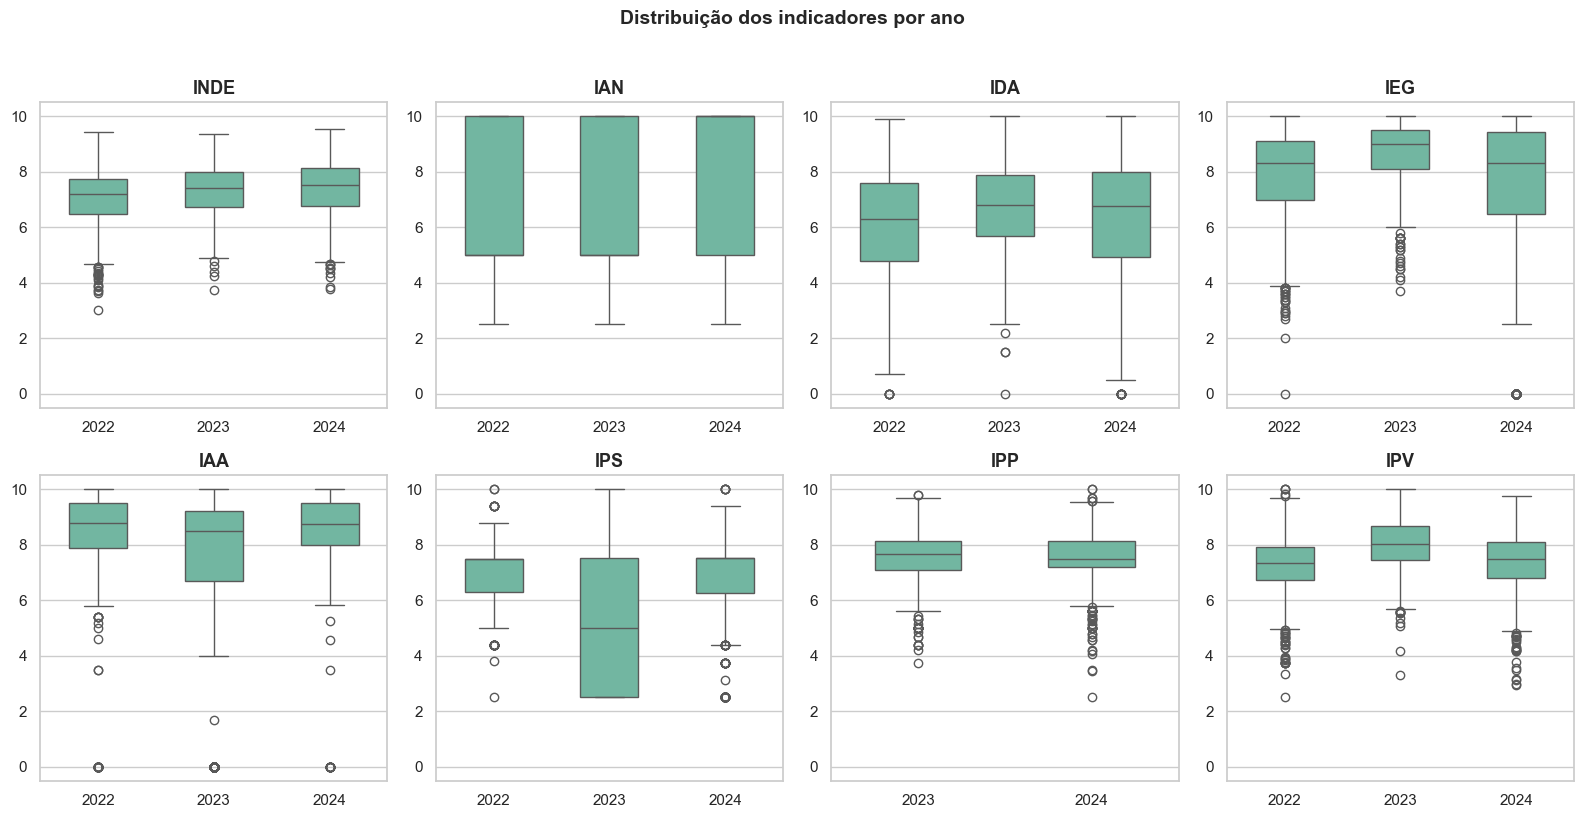

In [17]:
indicadores = ["inde", "ian", "ida", "ieg", "iaa", "ips", "ipp", "ipv"]

fig, axes = plt.subplots(2, 4, figsize=(16, 8))
for ax, ind in zip(axes.flat, indicadores):
    dados = alunos[["ano", ind]].dropna()
    sns.boxplot(data=dados, x="ano", y=ind, ax=ax, width=0.5)
    ax.set_title(ind.upper(), fontweight="bold")
    ax.set_xlabel("")
    ax.set_ylabel("")
    ax.set_ylim(-0.5, 10.5)

plt.suptitle("Distribuição dos indicadores por ano", fontsize=14, y=1.02, fontweight="bold")
plt.tight_layout()
plt.show()

leitura:

- INDE sobe consistentemente (7.04 → 7.34 → 7.40) — programa funcionando
- IAN é praticamente categórico (valores 2.5, 5.0, 10.0) por construção da fórmula — faz sentido, é defasagem discreta
- IEG caiu forte em 2024 (mediana 9.0 → 8.33) — ponto de atenção
- IPS em 2023 está muito abaixo de 2022 e 2024 — anomalia
- IPP só existe a partir de 2023 (boxplot vazio em 2022 é esperado)

### 7.2 evolução da média do INDE por fase e ano

agora olho pra efetividade do programa: dentro de cada fase, o INDE médio melhora ano a ano?

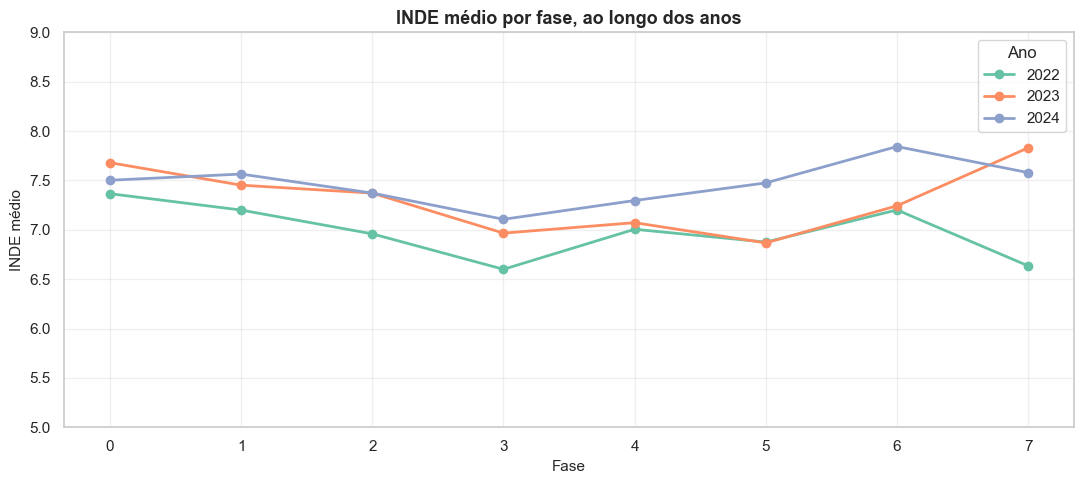

In [18]:
evolucao = alunos.groupby(["ano", "fase"])["inde"].mean().unstack(level=0)

fig, ax = plt.subplots(figsize=(11, 5))
evolucao.plot(marker="o", ax=ax, linewidth=2)
ax.set_title("INDE médio por fase, ao longo dos anos", fontweight="bold")
ax.set_xlabel("Fase")
ax.set_ylabel("INDE médio")
ax.set_ylim(5, 9)
ax.legend(title="Ano")
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### 7.3 matriz de correlação dos indicadores

uma das perguntas de negócio é se IEG tem relação direta com IDA e IPV — a matriz abaixo responde de primeira vista.

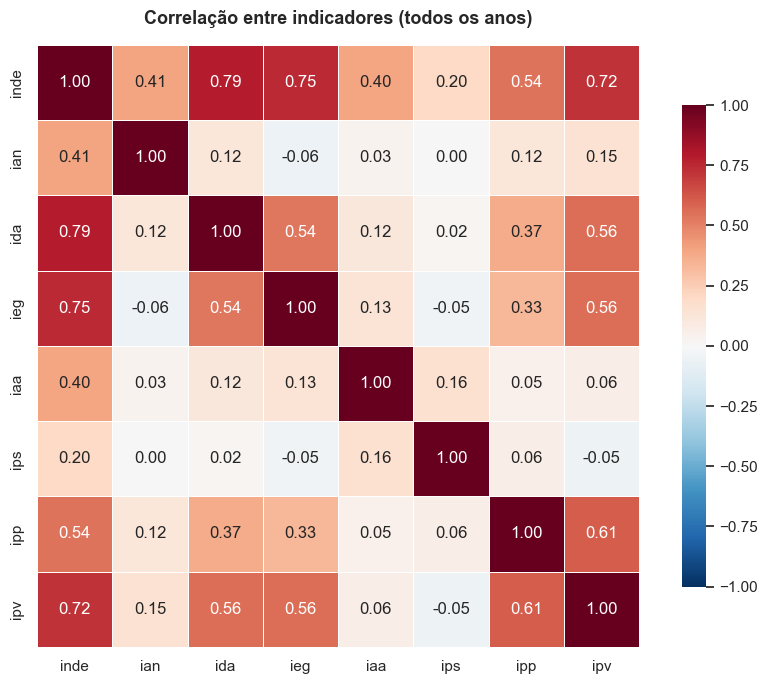

In [19]:
corr_cols = ["inde", "ian", "ida", "ieg", "iaa", "ips", "ipp", "ipv"]
corr = alunos[corr_cols].corr()

fig, ax = plt.subplots(figsize=(9, 7))
sns.heatmap(
    corr,
    annot=True, fmt=".2f",
    cmap="RdBu_r", center=0, vmin=-1, vmax=1,
    square=True, linewidths=0.5, ax=ax,
    cbar_kws={"shrink": 0.8},
)
ax.set_title("Correlação entre indicadores (todos os anos)", fontweight="bold", pad=15)
plt.tight_layout()
plt.show()

insights imediatos:

- INDE correlaciona forte com IDA e IPV (esperado — são componentes pesados na fórmula)
- IEG ↔ IPV é alta, confirmando a pergunta de negócio P3 (engajamento prediz ponto de virada)
- IAN é o mais descolado (quase ortogonal) — é o indicador mais estrutural, depende da idade/série não do comportamento

### 7.4 INDE por pedra (sanity check)

a pedra é atribuída a partir de faixas fixas de INDE. os boxplots devem ser basicamente degraus sem sobreposição — esse é o sanity check de que a base está consistente.

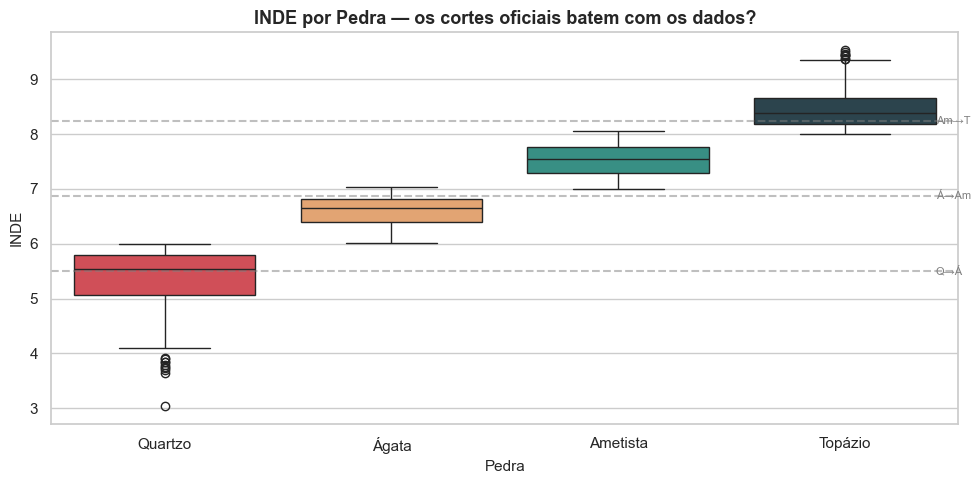

In [20]:
ordem_pedras = ["Quartzo", "Ágata", "Ametista", "Topázio"]
dados_pedra = alunos.dropna(subset=["pedra", "inde"])
dados_pedra = dados_pedra[dados_pedra["pedra"].isin(ordem_pedras)]

fig, ax = plt.subplots(figsize=(10, 5))
sns.boxplot(
    data=dados_pedra,
    x="pedra", y="inde",
    order=ordem_pedras,
    palette=["#e63946", "#f4a261", "#2a9d8f", "#264653"],
    ax=ax,
)
# Linhas de corte oficiais do PEDE
for y, label in [(5.506, "Q→Á"), (6.868, "Á→Am"), (8.230, "Am→T")]:
    ax.axhline(y, color="gray", linestyle="--", alpha=0.5)
    ax.text(3.4, y, label, fontsize=8, color="gray", va="center")

ax.set_title("INDE por Pedra — os cortes oficiais batem com os dados?", fontweight="bold")
ax.set_xlabel("Pedra")
ax.set_ylabel("INDE")
plt.tight_layout()
plt.show()

## 8. investigação dos padrões anômalos

três padrões estranhos detectados no diagnóstico merecem investigação:

1. IPS em 2023 — mediana cai de 7.5 (2022) para 5.0 (2023) e volta pra 7.5 (2024). mudança metodológica?
2. IEG em 2024 — queda forte (mediana 9.0 → 8.33)
3. "INCLUIR" em 2024 — 38 alunos com pedra fantasma

### 8.1 anomalia do IPS em 2023

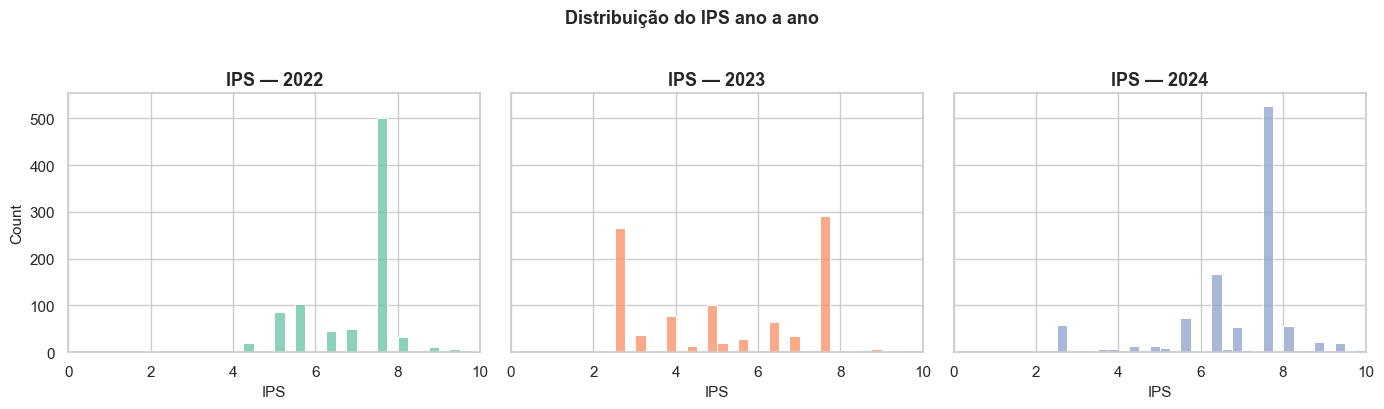


Percentis do IPS:
  2022: mediana=7.50, p25=6.30, p75=7.50, n=860
  2023: mediana=5.00, p25=2.52, p75=7.52, n=945
  2024: mediana=7.51, p25=6.26, p75=7.51, n=1054


In [21]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4), sharey=True)
for ax, ano in zip(axes, [2022, 2023, 2024]):
    sns.histplot(
        alunos[alunos["ano"] == ano]["ips"].dropna(),
        bins=30, ax=ax, color=sns.color_palette("Set2")[ano - 2022],
    )
    ax.set_title(f"IPS — {ano}", fontweight="bold")
    ax.set_xlabel("IPS")
    ax.set_xlim(0, 10)

plt.suptitle("Distribuição do IPS ano a ano", fontsize=13, y=1.02, fontweight="bold")
plt.tight_layout()
plt.show()

print("\nPercentis do IPS:")
for ano in [2022, 2023, 2024]:
    s = alunos[alunos["ano"] == ano]["ips"].dropna()
    print(f"  {ano}: mediana={s.median():.2f}, p25={s.quantile(0.25):.2f}, p75={s.quantile(0.75):.2f}, n={len(s)}")

hipótese: em 2023 o IPS parece bimodal — uma concentração grande perto de 2.5 (piso) e outra em 7.5. isso geralmente indica mudança metodológica (nova equipe de psicologia, nova escala, novo critério). em 2024 volta ao padrão de 2022.

decisão: não toco no dado. registro o achado como insight livre pra apresentação executiva e evito tirar conclusões causais a partir de comparações IPS 2022 vs 2023. se virar feature do modelo, uso IPS normalizado dentro do ano (z-score), nunca valor absoluto entre anos.

### 8.2 queda do IEG em 2024

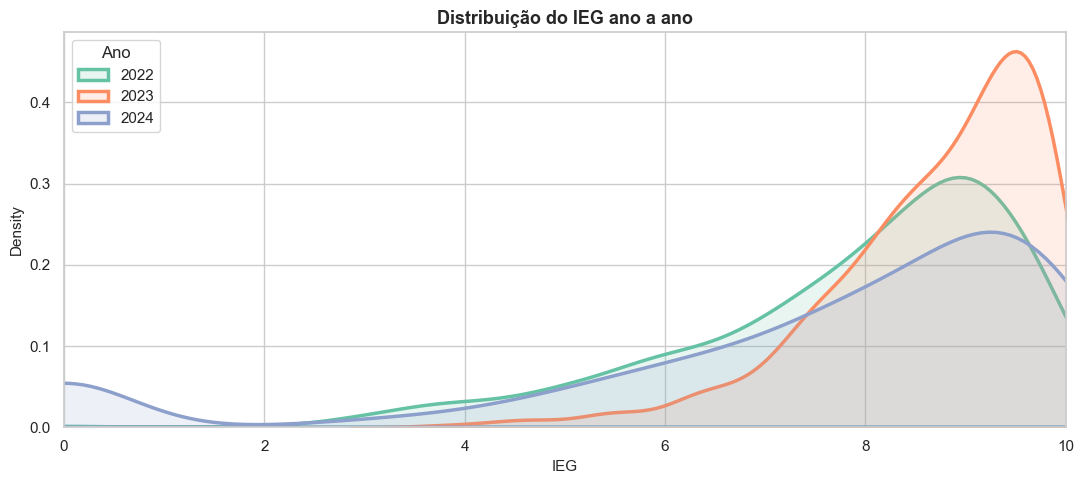


IEG médio por fase — 2023 vs 2024:
ano   2023  2024
fase            
0     8.94  8.50
1     8.74  8.49
2     8.80  7.96
3     8.44  7.39
4     8.35  7.95
5     8.45  8.47
6     8.50  8.80
7     9.17  7.44
8      NaN  0.00
9      NaN  0.00

Delta 2024 - 2023 por fase:
fase
0   -0.44
1   -0.25
2   -0.84
3   -1.05
4   -0.41
5    0.02
6    0.30
7   -1.73
8     NaN
9     NaN


In [22]:
fig, ax = plt.subplots(figsize=(11, 5))
for ano in [2022, 2023, 2024]:
    sns.kdeplot(
        alunos[alunos["ano"] == ano]["ieg"].dropna(),
        ax=ax, label=str(ano), linewidth=2.5, fill=True, alpha=0.15,
    )
ax.set_title("Distribuição do IEG ano a ano", fontweight="bold")
ax.set_xlabel("IEG")
ax.set_xlim(0, 10)
ax.legend(title="Ano")
plt.tight_layout()
plt.show()

# IEG por fase em 2024 vs 2023
ieg_fase = alunos[alunos["ano"].isin([2023, 2024])].groupby(["ano", "fase"])["ieg"].mean().unstack("ano")
print("\nIEG médio por fase — 2023 vs 2024:")
print(ieg_fase.round(2))
print("\nDelta 2024 - 2023 por fase:")
print((ieg_fase[2024] - ieg_fase[2023]).round(2).to_string())

a queda de IEG em 2024 é transversal — acontece em quase todas as fases, não é problema de uma turma específica. pode indicar algo sistêmico: fadiga pós-pandemia persistente, mudança no método de avaliação de engajamento, ou o aumento do tamanho do programa diluindo a atenção por aluno (1156 alunos em 2024 vs 1014 em 2023 = +14%).

insight forte pra apresentação executiva.

### 8.3 os 102 alunos sem pedra em 2024 — quem são?

In [23]:
sem_pedra_mask = (alunos["ano"] == 2024) & (alunos["pedra"].isna())
sem_pedra = alunos[sem_pedra_mask].copy()

print(f"Alunos sem pedra em 2024: {len(sem_pedra)}")
print(f"\nDistribuição por fase:")
print(sem_pedra["fase"].value_counts().sort_index())
print(f"\nIdade por fase:")
print(sem_pedra.groupby("fase")["idade"].describe()[["count", "mean", "min", "max"]].round(1))
print(f"\nAno de ingresso no programa:")
print(sem_pedra["ano_ingresso"].value_counts().sort_index())
print(f"\nQuantos têm INDE preenchido? {sem_pedra['inde'].notna().sum()}")

Alunos sem pedra em 2024: 102

Distribuição por fase:
fase
8    64
9    38
Name: count, dtype: int64

Idade por fase:
      count  mean   min   max
fase                         
8      64.0  20.0  18.0  27.0
9      38.0  21.8  20.0  25.0

Ano de ingresso no programa:
ano_ingresso
2021    86
2022    12
2023     4
Name: count, dtype: int64

Quantos têm INDE preenchido? 0


descoberta: os 102 alunos sem pedra em 2024 são todos do ensino superior:

- 64 alunos na fase 8 (1º-3º ano universitário, idade média 20)
- 38 alunos na fase 9 (universitários pós-fase-8, idade média 22, rotulados "INCLUIR" no xlsx)

86 deles ingressaram em 2021. não são novos ingressantes do programa — são alunos antigos que envelheceram e saíram do alcance do sistema tradicional de pedras do PEDE, que foi desenhado pra fundamental e médio.

isso diz algo importante sobre a Passos: a ONG está num momento de transição estrutural — começou focada em crianças e adolescentes e agora precisa criar ferramentas de avaliação pra ensino superior. o PEDE original não contempla esses alunos. é insight de negócio forte pra apresentação: o programa amadureceu com seus alunos, é hora do PEDE amadurecer junto.

impacto no modelo preditivo: esses 102 vão ser automaticamente excluídos da modelagem porque não têm INDE (que é a variável-base pro target). mas seguem na análise descritiva — são parte da história da ONG.

## 9. retenção e evasão — base de pares (t, t+1)

essa análise é central pra viabilidade do modelo forward-looking: preciso entender quantos pares (ano t, ano t+1) tenho disponíveis.

In [24]:
ra_por_ano = {ano: set(alunos[alunos["ano"] == ano]["ra"]) for ano in [2022, 2023, 2024]}

print("Retenção ano-a-ano:")
print(f"  2022 → 2023: {len(ra_por_ano[2022] & ra_por_ano[2023]):4d} de {len(ra_por_ano[2022])} "
      f"({len(ra_por_ano[2022] & ra_por_ano[2023]) / len(ra_por_ano[2022]) * 100:.1f}%)")
print(f"  2023 → 2024: {len(ra_por_ano[2023] & ra_por_ano[2024]):4d} de {len(ra_por_ano[2023])} "
      f"({len(ra_por_ano[2023] & ra_por_ano[2024]) / len(ra_por_ano[2023]) * 100:.1f}%)")
print(f"\nPresentes nos 3 anos: {len(ra_por_ano[2022] & ra_por_ano[2023] & ra_por_ano[2024])}")
print(f"\nApenas 2022: {len(ra_por_ano[2022] - ra_por_ano[2023] - ra_por_ano[2024])}")
print(f"Apenas 2023: {len(ra_por_ano[2023] - ra_por_ano[2022] - ra_por_ano[2024])}")
print(f"Apenas 2024: {len(ra_por_ano[2024] - ra_por_ano[2022] - ra_por_ano[2023])}")

Retenção ano-a-ano:
  2022 → 2023:  600 de 860 (69.8%)
  2023 → 2024:  765 de 1014 (75.4%)

Presentes nos 3 anos: 468

Apenas 2022: 256
Apenas 2023: 117
Apenas 2024: 387


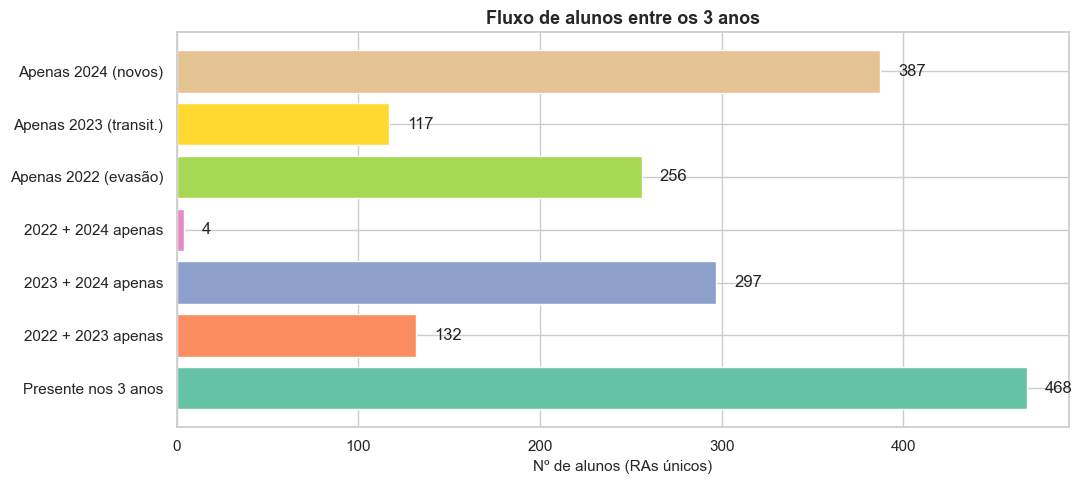

In [25]:
# Diagrama de fluxo
categorias = {
    "Presente nos 3 anos": len(ra_por_ano[2022] & ra_por_ano[2023] & ra_por_ano[2024]),
    "2022 + 2023 apenas": len((ra_por_ano[2022] & ra_por_ano[2023]) - ra_por_ano[2024]),
    "2023 + 2024 apenas": len((ra_por_ano[2023] & ra_por_ano[2024]) - ra_por_ano[2022]),
    "2022 + 2024 apenas": len((ra_por_ano[2022] & ra_por_ano[2024]) - ra_por_ano[2023]),
    "Apenas 2022 (evasão)": len(ra_por_ano[2022] - ra_por_ano[2023] - ra_por_ano[2024]),
    "Apenas 2023 (transit.)": len(ra_por_ano[2023] - ra_por_ano[2022] - ra_por_ano[2024]),
    "Apenas 2024 (novos)": len(ra_por_ano[2024] - ra_por_ano[2022] - ra_por_ano[2023]),
}

fig, ax = plt.subplots(figsize=(11, 5))
cores = sns.color_palette("Set2", len(categorias))
bars = ax.barh(list(categorias.keys()), list(categorias.values()), color=cores)
ax.set_title("Fluxo de alunos entre os 3 anos", fontweight="bold")
ax.set_xlabel("Nº de alunos (RAs únicos)")
for bar, valor in zip(bars, categorias.values()):
    ax.text(bar.get_width() + 10, bar.get_y() + bar.get_height() / 2, str(valor), va="center")
plt.tight_layout()
plt.show()

implicações diretas pro modelo:

- treino (pares 2022→2023): 600 alunos
- teste (pares 2023→2024): 765 alunos
- total: 1365 pares aluno-ano pra modelagem

dataset é pequeno mas suficiente pra GBMs tabulares. e os ~250 alunos que evadiram entre 2022-2023 são ouro pra análise descritiva — uma das perguntas de insights livres da etapa 3 vai investigar quem evade e se o modelo conseguiria ter previsto.

## 10. export

salvo o dataset limpo em `data/processed/alunos_long.parquet`. todos os notebooks seguintes vão ler desse arquivo, não do xlsx original.

In [26]:
OUTPUT_PATH = DATA_PROCESSED / "alunos_long.parquet"
alunos.to_parquet(OUTPUT_PATH, index=False)

print(f"✅ Salvo em: {OUTPUT_PATH.relative_to(PROJECT_ROOT)}")
print(f"   Shape:   {alunos.shape}")
print(f"   Tamanho: {OUTPUT_PATH.stat().st_size / 1024:.1f} KB")

# Sanity read-back
rb = pd.read_parquet(OUTPUT_PATH)
assert rb.shape == alunos.shape
print(f"\n✅ Read-back OK — arquivo legível e íntegro")

✅ Salvo em: data/processed/alunos_long.parquet
   Shape:   (3030, 27)
   Tamanho: 110.0 KB

✅ Read-back OK — arquivo legível e íntegro


## resumo da etapa 2

dataset consolidado:

- 3030 linhas × 27 colunas (860 + 1014 + 1156, um por aluno-ano)
- schema canônico com nomes em `snake_case`
- chave (ra, ano) garantidamente única
- exportado em `data/processed/alunos_long.parquet`

principais achados:

1. schema inconsistente entre anos — resolvido com funções de limpeza por aba
2. IPP não existe em 2022 — limita features temporais desse indicador a 2023→2024
3. inglês 64% missing estrutural — criada feature `tem_nota_ingles`
4. idade 2023 com bug de datetime — corrigido via `.day`
5. 102 alunos universitários sem pedra em 2024 — 64 na fase 8 + 38 na fase 9, todos ingressaram entre 2021-2023. o sistema de pedras do PEDE não contempla ensino superior. insight forte pra apresentação.
6. IPS 2023 anômalo (bimodal, mediana 5) — provável mudança metodológica. insight livre.
7. IEG em queda em 2024 — transversal entre fases, insight livre forte
8. retenção ano-a-ano ~70-75% — base de 1365 pares (t, t+1) pra modelagem

próximo passo: etapa 3 — análise das 11 perguntas de negócio (`02_perguntas_negocio.ipynb`).